# Task 5 — Personal Loan Acceptance Prediction

## Objective

The objective of this task is to predict which customers are likely to accept a personal loan offer using machine learning techniques.

## Tools Used

- Python
- pandas
- matplotlib
- seaborn
- scikit-learn


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## Loading Dataset


In [8]:
df = pd.read_csv("bank.csv")

## Dataset Overview


In [3]:
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

First 5 Rows:
  age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0  59,admin.,married,secondary,no,2343,yes,no,unk...                                                                        
1  56,admin.,married,secondary,no,45,no,no,unknow...                                                                        
2  41,technician,married,secondary,no,1270,yes,no...                                                                        
3  55,services,married,secondary,no,2476,yes,no,u...                                                                        
4  54,admin.,married,tertiary,no,184,no,no,unknow...                                                                        

Dataset Shape:
(11162, 1)

Column Names:
Index(['age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit'], dtype='str')


## Dataset Information


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 1 columns):
 #   Column                                                                                                                      Non-Null Count  Dtype
---  ------                                                                                                                      --------------  -----
 0   age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit  11162 non-null  str  
dtypes: str(1)
memory usage: 87.3 KB
None


## Checking Missing Values


In [5]:
print(df.isnull().sum())

age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit    0
dtype: int64


## Encoding Categorical Columns

Machine learning models cannot work directly with text data, so categorical columns are converted into numerical values.


In [6]:
from sklearn.preprocessing import LabelEncoder

# Create copy for ML
df_ml = df.copy()

# Encode categorical columns
for col in df_ml.select_dtypes(include=["object", "string"]).columns:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])

## Age Distribution

This graph shows the distribution of customer ages.


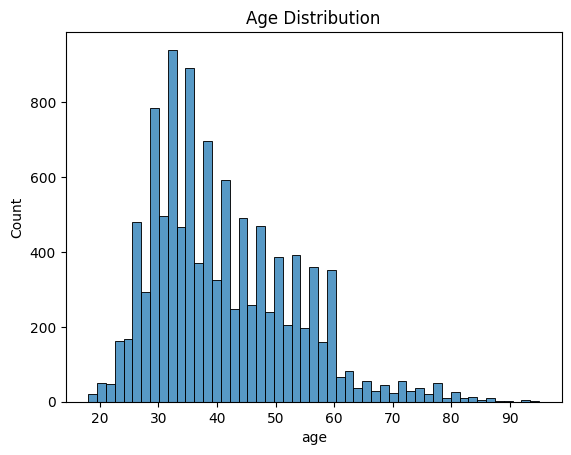

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["age"])
plt.title("Age Distribution")
plt.show()

## Marital Status Analysis

This graph shows the number of customers in different marital categories.


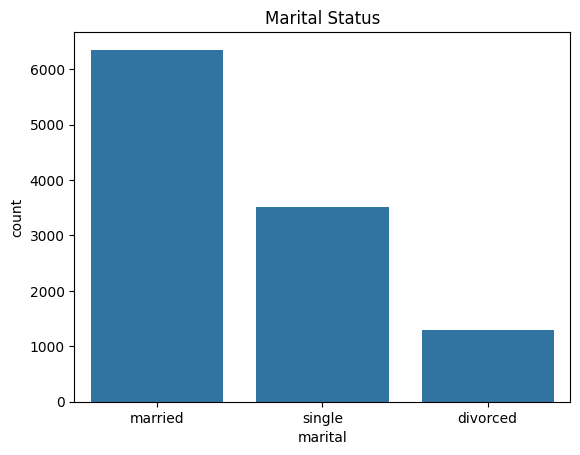

In [ ]:
sns.countplot(x="marital", data=df)

plt.title("Marital Status")

plt.show()

## Job Category Analysis

This graph shows the distribution of different job categories.


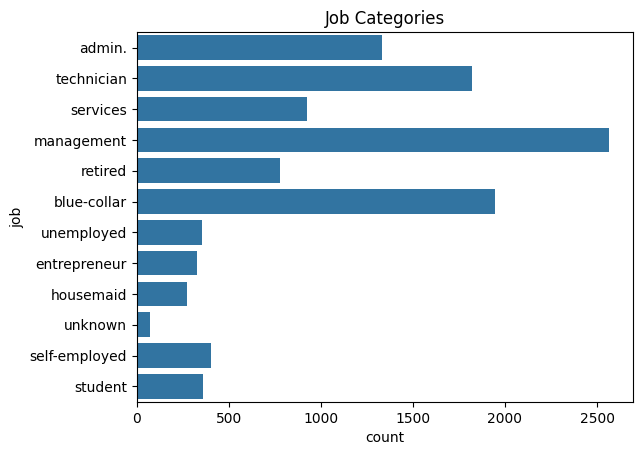

In [ ]:
sns.countplot(y="job", data=df)

plt.title("Job Categories")

plt.show()

## Preparing Features and Target Variable


In [ ]:
X = df_ml.drop("deposit", axis=1)

y = df_ml["deposit"]

## Splitting the Dataset

The dataset is divided into training data and testing data.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
## Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Training Logistic Regression Model


In [ ]:
## Training Logistic Regression Model

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Making Predictions


In [ ]:
predictions = model.predict(X_test)

## Model Accuracy


In [ ]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8087774294670846


## Confusion Matrix


In [ ]:
cm = confusion_matrix(y_test, predictions)

print(cm)

[[972 194]
 [233 834]]


In [ ]:
## Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1166
           1       0.81      0.78      0.80      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



# Key Insights

- Customer age influences loan acceptance behavior.
- Different marital groups respond differently to loan offers.
- Job categories affect customer decisions.
- Logistic Regression predicts customer responses with reasonable accuracy.


# Conclusion

This project used the Bank Marketing dataset to predict customer loan acceptance using Logistic Regression. Data analysis and visualizations helped identify important customer behavior patterns and evaluate model performance.
